In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from pandas import DataFrame
# ========================================
# 鸢尾花分类 — 朴素贝叶斯入门示例
# 数据集：Iris (150样本, 3类, 4特征)
# ========================================

# 1. 加载数据集
from sklearn import datasets
iris = datasets.load_iris()       # 加载鸢尾花数据集（sklearn内置经典数据集）
X = iris.data                     # 特征矩阵 (150行 × 4列): 花萼长/花萼宽/花瓣长/花瓣宽
y = iris.target                   # 标签向量 (150,): 0=山鸢尾, 1=变色鸢尾, 2=维吉尼亚鸢尾

p = iris.data
q = iris.target

# 2. 划分训练集和测试集
# 防止数据泄露导致训练成果无效，所以切分数据集为：1.训练集 2.测试集
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,               # 测试集占25% → 测试集38条, 训练集112条
    random_state=1                # 随机种子，固定后每次划分结果一致（可复现）
)

# 这是一个故意把训练集样本数量拉低的对照组，目的是为了验证训练集样本数量减少，这种训练数据不足的情况下，模型评估数据会如何变化
p_train, p_test, q_train, q_test = train_test_split(
    p, q,
    test_size=0.75,               # 测试集占75% → 训练集38条, 测试集112条（故意反过来，体会数据量的影响）
    random_state=1                # 随机种子，固定后每次划分结果一致（可复现）
)

# 3. 训练模型 — 高斯朴素贝叶斯
from sklearn.naive_bayes import GaussianNB
xymodel = GaussianNB()              # 假设每个特征在各类别下服从高斯分布(正态分布)
xymodel.fit(x_train, y_train)       # 训练：计算每个类别的均值、方差、先验概率

pqmodel = GaussianNB()
pqmodel.fit(p_train, q_train)

# 4. 评估模型
from sklearn import metrics
y_pred = xymodel.predict(x_test)    # 对测试集做预测
print(metrics.classification_report(
    y_test,                       # 真实标签
    y_pred                        # 预测标签
))

q_pred = pqmodel.predict(p_test)
print(metrics.classification_report(
    q_test,
    q_pred
))
# 分类报告包含: precision(精确率), recall(召回率), f1-score, accuracy(准确率)
# — 只有38条训练数据，结果不会太好，但这是故意让你感受"数据量不够"的效果

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.97      0.92      0.94        36
           2       0.93      0.97      0.95        40

    accuracy                           0.96       113
   macro avg       0.97      0.96      0.96       113
weighted avg       0.97      0.96      0.96       113



In [9]:
'''
在结果中，0、1、2分别代表山鸢尾、变色鸢尾花、维吉尼亚鸢尾。
recall代表召回率，recall * support = 真正召回的数量，也就是成功预测的数量。

在第一个xymodel的预测中，0号山鸢尾花的召回率recall = 1，support = 13，证明全部召回。
1号变色鸢尾花召回率recall = 0.94，support = 16，recall * support = 15，说明漏掉了1棵，被预测成了其他的类型。

重点在2号维吉尼亚鸢尾花：
precision = 0.90 = 9 / 10，这个代表预测的正确率，90%预测正确，另外有10%预测失败，就是上面的1号变色鸢尾花，预测成了2号维吉尼亚鸢尾花。

重点辨析precision 和 recall：
precision代表准确度，recall代表召回率。
2号的召回率为1，说明所有的2号样本都成功预测成了2号。
2号的正确率为0.9，说明被识别成2号的样本里面，只有9成的样本确实是2号，另外1成的样本是错误预测。


另有3个汇总指标
accuracy代表整体正确率，因为总共38个样本，其中有一个1号样本被识别成了2号，所以就是这一个样本识别错误，正确率为37/38 ≈ 0.97.

macro

  ┌──────────────┬────────────────┬──────────────────────────────┐
  │     指标      │       值        │           怎么算的            │
  ├──────────────┼────────────────┼──────────────────────────────┤
  │ accuracy     │ 0.97           │ 37/38，整体正确率              │
  ├──────────────┼────────────────┼──────────────────────────────┤
  │ macro avg    │ 0.97/0.98/0.97 │ 三个类直接平均，不管样本多少       │
  ├──────────────┼────────────────┼──────────────────────────────┤
  │ weighted avg │ 0.98/0.97/0.97 │ 按13:16:9加权，大类别权重大      │
  └──────────────┴────────────────┴──────────────────────────────┘
'''

'\n在结果中，0、1、2分别代表山鸢尾、变色鸢尾花、维吉尼亚鸢尾。\n'

In [12]:
'''
接下来是DataFrame的训练
DataFrame创建方法为：DataFrame(data,index=[],columns=[]))
data 代表 “数据”
index 代表 “行索引列表”
columns 代表 “列索引列表”
'''
import pandas as pd

data = [
    [80,74,89,66,90],
    [84,77,87,96,90],
    [74,84,83,71,85],
    [75,66,85,89,90],
    [66,50,63,67,80],
    [67,76,85,74,80]
]

GradeTable = pd.DataFrame(data, index = ['max','doyle','grics','cinderella','anna','marks'],columns = ['grade','grade1','grade2','grade3','grade4'])

GradeTable

'''
很基础的一个二维表创建，涉及到的还有一维索引表，没什么特别的难度，
重点理解index、columns，以及data，引用pandas DataFrame
数据访问方式和单维访问方式相同，不做详细解析。
'''

,grade,grade1,grade2,grade3,grade4
max,80,74,89,66,90
doyle,84,77,87,96,90
grics,74,84,83,71,85
cinderella,75,66,85,89,90
anna,66,50,63,67,80
marks,67,76,85,74,80


In [ ]:
'''
Matplotlib库-绘制图形

说起这个，我就会想起Matlab，因为曾经学习过一些脑电信号处理的知识，Matlab可以给出很直观的热力图反馈和简单的点击式数据清洗方案。

下面是Matplotlib涉及到的关键词，如果熟悉可以不同看：

X：x轴数据
Y：y轴数据
kind：绘图类型参数
title：标题
color：颜色
grid：网格
fontsize：字体
alpha：图表透明度
use_index：默认true，使用索引作为X轴坐标
linewidth：绘图线宽
linestyle：绘图线型
marker：标记风格
xlim，ylim：x范围，y范围
ax：axes对象
'''

'''
plt.title               设置图标题
plt.legend              添加图例说明
plt.xlabel  plt.ylabel  设置x、y标题
plt.grid                显示网格线
plt.xlim    plt.ylim    设置x、y轴刻度范围
plt.text                添加注解文字
plt.xticks  plt.yticks  设置x、y刻度值
plt.annotate            添加注释
'''

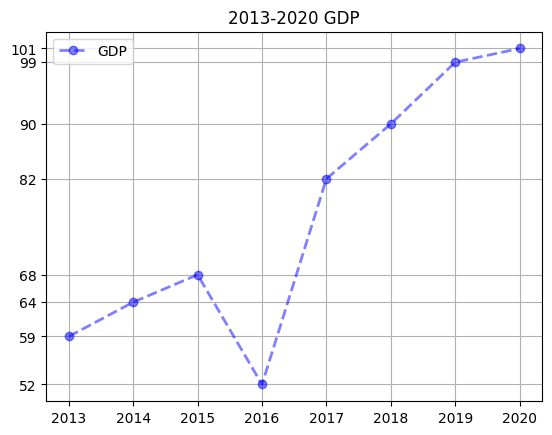

In [13]:
'''
PLT快速绘图
'''

'''
pandas绘图
这里的y轴刻度线是直接和数据对齐的，因为我偷懒了，yticks = [59,64,68,52,82,90,99,101]，所以能看到刻度是和折线转折点重合的。

其实这种集中式的写法我更喜欢，这是我的性格问题，matplotlab是一个分散式的写法，自定义性更强，下面可以展示
'''
from pandas import DataFrame
import matplotlib.pyplot as plt

# 数据准备
gdp = [59,64,68,52,82,90,99,101]
data = DataFrame({'GDP':gdp},index=['2013','2014','2015','2016','2017','2018','2019','2020'])

# 图表自定义
data.plot(kind = 'line',title = '2013-2020 GDP', linewidth = 2, color = 'blue',marker = 'o', linestyle = 'dashed',grid = True,alpha = 0.5, yticks = [59,64,68,52,82,90,99,101])

plt.show()

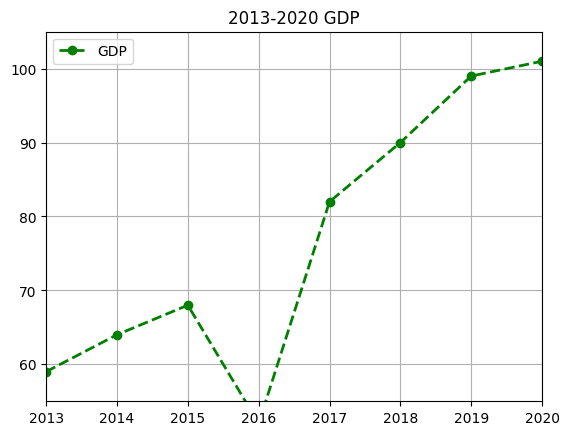

In [17]:
'''
Matplotlib绘图
这里我专门设计了一个非常低的数值，很明显看到数据击穿面板了，这就是ylim设置不合理导致的
'''
from pandas import DataFrame
import matplotlib.pyplot as plt

# 初始化绘图对象
plt.figure()

# 数据准备,这里不再需要DataFrame
gdp = [59,64,68,52,82,90,99,101]


# 直接在这里植入gdp数据
# 直接用plt，而不是用data的pandas用法
plt.plot(gdp, color = "green", linewidth = 2, linestyle = "dashed", marker = 'o', label = "GDP")

plt.title('2013-2020 GDP')
plt.xlim(0,7)
plt.ylim(55,105)
plt.xticks(range(0,8),('2013','2014','2015','2016','2017','2018','2019','2020'))
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

In [ ]:
'''
基本的图像数据处理到此为止，更进阶的会涉及到数据清洗、数据合并、空值填充，但那需要以现成数据作为参考，为了提高效率，将这方面学习直接融入到我们之后的章节中
'''